In [ ]:
from google.colab import drive
drive.mount('/content/drive')

WORKING LINE SEGMENTATION

Displaying Line 1


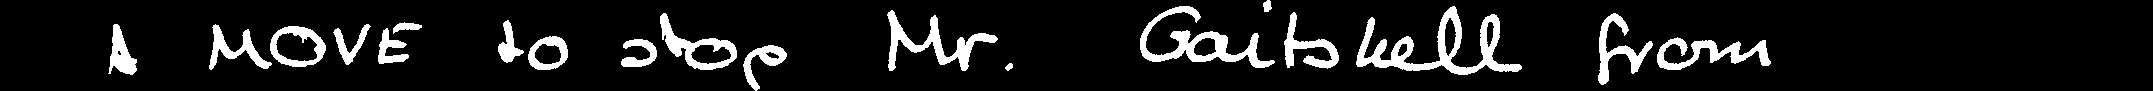

Displaying Line 2


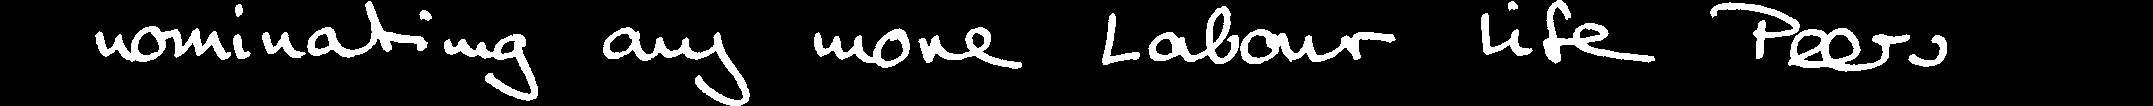

Displaying Line 3


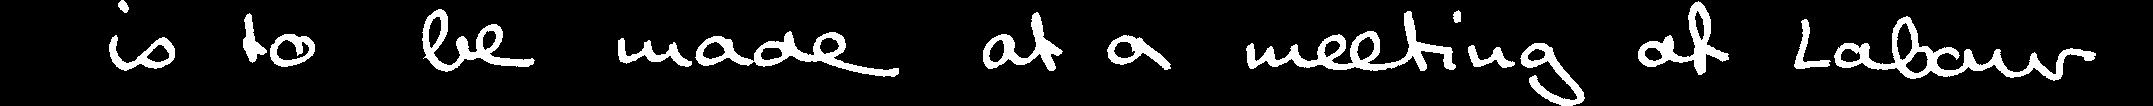

In [ ]:
import cv2
import numpy as np
from google.colab.patches import cv2_imshow

class ProperLineSegmentation:
    def __init__(self):
        pass

    def preprocess(self, image):
        """ Convert to grayscale and apply binarization """
        gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
        _, binary = cv2.threshold(gray, 0, 255, cv2.THRESH_BINARY_INV + cv2.THRESH_OTSU)
        return binary

    def project_horizontal_histogram(self, binary_img):
        """ Compute the horizontal histogram projection to detect lines """
        hist = np.sum(binary_img, axis=1)  # Sum of white pixels per row
        return hist

    def segment_lines(self, image, min_gap=10):
        """ Segment the image into text lines based on projection profile """
        binary = self.preprocess(image)
        hist = self.project_horizontal_histogram(binary)

        # Detecting valleys (gaps between text lines)
        line_positions = []
        in_line = False
        for i, value in enumerate(hist):
            if value > 0:  # If there is text in this row
                if not in_line:
                    start = i
                    in_line = True
            else:  # Empty row
                if in_line:
                    end = i
                    if end - start > min_gap:  # Ensure minimum height for valid lines
                        line_positions.append((start, end))
                    in_line = False

        # Extract segmented lines
        lines = []
        for (start, end) in line_positions:
            line = binary[start:end, :]  # Extract full-width line
            lines.append(line)

        return lines

# === Run Segmentation ===
if __name__ == "__main__":
    img = cv2.imread("/content/drive/MyDrive/ocrtest.png")  # Replace with actual image path
    segmenter = ProperLineSegmentation()

    # Segment lines
    lines = segmenter.segment_lines(img)

    # Display results
    for idx, line in enumerate(lines):
        print(f"Displaying Line {idx+1}")
        cv2_imshow(line)  # Show segmented lines


LINE SEGMENTATION + TROCR

Using a slow image processor as `use_fast` is unset and a slow processor was saved with this model. `use_fast=True` will be the default behavior in v4.52, even if the model was saved with a slow processor. This will result in minor differences in outputs. You'll still be able to use a slow processor with `use_fast=False`.
Config of the encoder: <class 'transformers.models.vit.modeling_vit.ViTModel'> is overwritten by shared encoder config: ViTConfig {
  "attention_probs_dropout_prob": 0.0,
  "encoder_stride": 16,
  "hidden_act": "gelu",
  "hidden_dropout_prob": 0.0,
  "hidden_size": 768,
  "image_size": 384,
  "initializer_range": 0.02,
  "intermediate_size": 3072,
  "layer_norm_eps": 1e-12,
  "model_type": "vit",
  "num_attention_heads": 12,
  "num_channels": 3,
  "num_hidden_layers": 12,
  "patch_size": 16,
  "pooler_act": "tanh",
  "pooler_output_size": 768,
  "qkv_bias": false,
  "torch_dtype": "float32",
  "transformers_version": "4.50.3"
}

Config of the decoder: <class 'transfor

Processing Line 1...


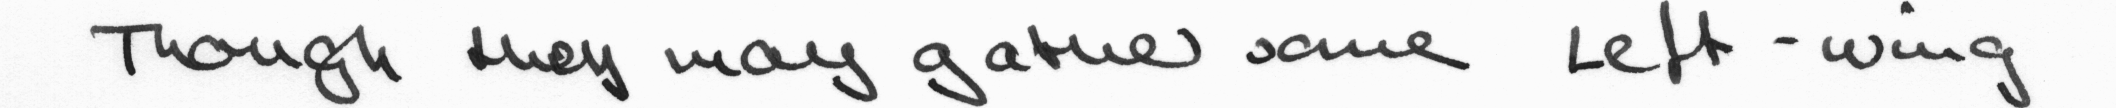

Processing Line 2...


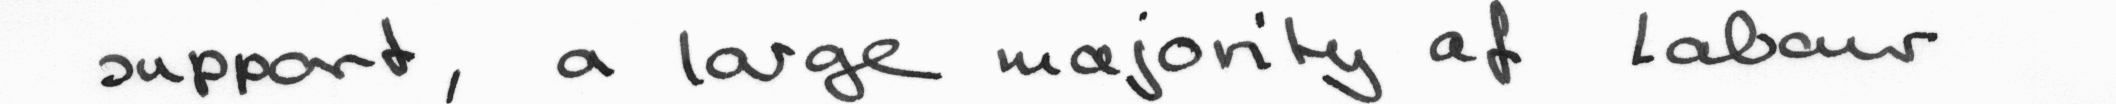

Processing Line 3...


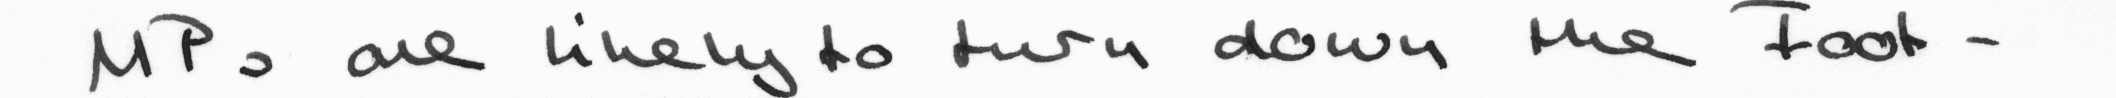

Processing Line 4...


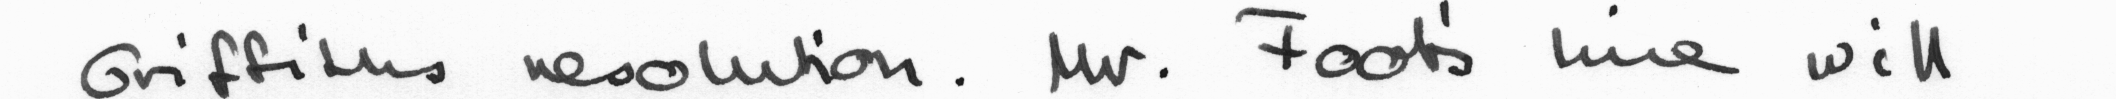

Processing Line 5...


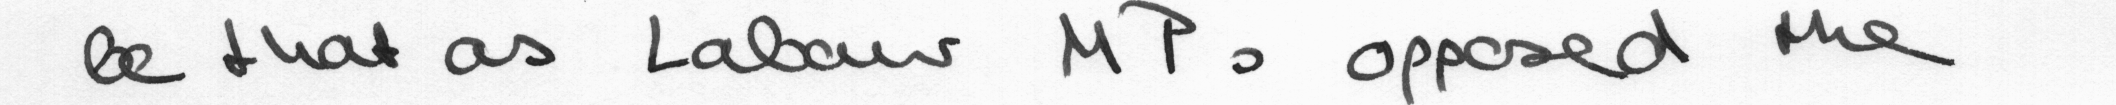

Processing Line 6...


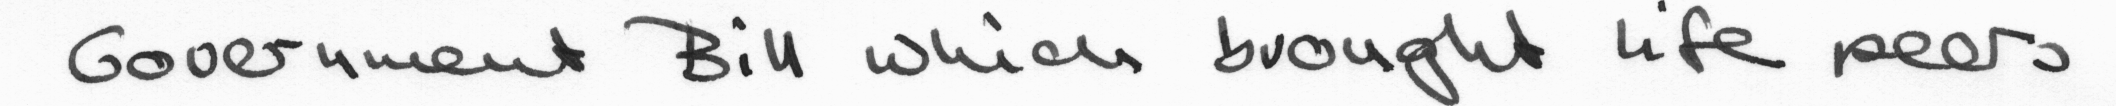

Processing Line 7...


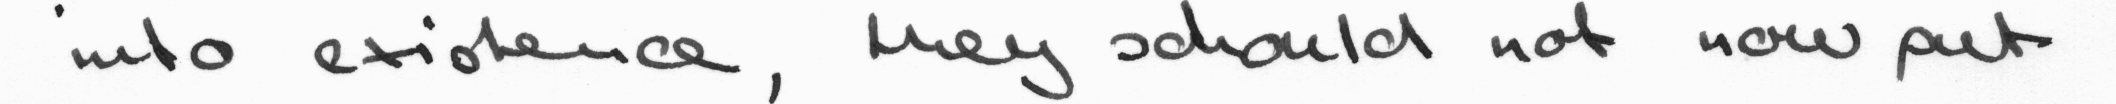


=== Final Recognized Text ===
 Though they may may gather some left-wing
support, a large majority at labour
Mrs are likely to turn down the foot-
Griffitus resolution. Mr.will will
be that as Labour MPs opposed
Government Bil which brought life means
into evidence, theynot not now put


In [ ]:
import cv2
import numpy as np
import torch
from transformers import VisionEncoderDecoderModel, TrOCRProcessor
from PIL import Image
from google.colab.patches import cv2_imshow

class ProperLineSegmentation:
    def __init__(self):
        pass

    def preprocess(self, image):
        """ Convert to grayscale and apply binarization """
        gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
        _, binary = cv2.threshold(gray, 0, 255, cv2.THRESH_BINARY_INV + cv2.THRESH_OTSU)
        return binary

    def project_horizontal_histogram(self, binary_img):
        """ Compute the horizontal histogram projection to detect lines """
        hist = np.sum(binary_img, axis=1)  # Sum of white pixels per row
        return hist

    def segment_lines(self, image, min_gap=10):
        """ Segment the image into text lines based on projection profile """
        binary = self.preprocess(image)
        hist = self.project_horizontal_histogram(binary)

        # Detecting valleys (gaps between text lines)
        line_positions = []
        in_line = False
        for i, value in enumerate(hist):
            if value > 0:  # If there is text in this row
                if not in_line:
                    start = i
                    in_line = True
            else:  # Empty row
                if in_line:
                    end = i
                    if end - start > min_gap:  # Ensure minimum height for valid lines
                        line_positions.append((start, end))
                    in_line = False

        # Extract segmented lines
        lines = []
        for (start, end) in line_positions:
            line = image[start:end, :]  # Extract full-width line
            lines.append(line)

        return lines

# === Load TrOCR Model ===
model_path = "/content/drive/MyDrive/trocr_model"

# Load processor and model
processor = TrOCRProcessor.from_pretrained(model_path)
model = VisionEncoderDecoderModel.from_pretrained(model_path)
device = "cuda" if torch.cuda.is_available() else "cpu"
model.to(device)

# === Run Line Segmentation and OCR ===
def recognize_text(image_path):
    img = cv2.imread(image_path)
    segmenter = ProperLineSegmentation()

    # Segment lines
    lines = segmenter.segment_lines(img)

    # Process each segmented line
    full_text = []
    for idx, line in enumerate(lines):
        print(f"Processing Line {idx+1}...")
        cv2_imshow(line)  # Show segmented line

        # Convert OpenCV image to PIL format
        if len(line.shape) == 2:  # Grayscale image
           line = cv2.cvtColor(line, cv2.COLOR_GRAY2BGR)  # Convert to 3 channels

        pil_image = Image.fromarray(line)


        # Preprocess and recognize text
        pixel_values = processor(pil_image, return_tensors="pt").pixel_values.to(device)
        with torch.no_grad():
            generated_ids = model.generate(pixel_values)
        text = processor.batch_decode(generated_ids, skip_special_tokens=True)[0]

        full_text.append(text)

    return "\n".join(full_text)

# === Run on an Example Image ===
image_path = "/content/drive/MyDrive/images/000002.png"  # Update with actual path
recognized_text = recognize_text(image_path)
print("\n=== Final Recognized Text ===\n", recognized_text)


WITH POSTPROCESSING

In [ ]:
!pip install pyspellchecker


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.1/7.1 MB 95.1 MB/s eta 0:00:00


/usr/local/lib/python3.11/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


preprocessor_config.json:   0%|          | 0.00/224 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/1.12k [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/899k [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/456k [00:00<?, ?B/s]

...

config.json:   0%|          | 0.00/4.17k [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/1.33G [00:00<?, ?B/s]

Config of the encoder: <class 'transformers.models.vit.modeling_vit.ViTModel'> is overwritten by shared encoder config: ViTConfig {
  "attention_probs_dropout_prob": 0.0,
  "encoder_stride": 16,
  "hidden_act": "gelu",
  "hidden_dropout_prob": 0.0,
  "hidden_size": 768,
  "image_size": 384,
  "initializer_range": 0.02,
  "intermediate_size": 3072,
  "layer_norm_eps": 1e-12,
  "model_type": "vit",
  "num_attention_heads": 12,
  "num_channels": 3,
  "num_hidden_layers": 12,
  "patch_size": 16,
  "pooler_act": "tanh",
  "pooler_output_size": 768,
  "qkv_bias": false,
  "torch_dtype": "float32",
  "transformers_version": "4.50.3"
}

Config of the decoder: <class 'transformers.models.trocr.modeling_trocr.TrOCRForCausalLM'> is overwritten by shared decoder config: TrOCRConfig {
  "activation_dropout": 0.0,
  "activation_function": "gelu",
  "add_cross_attention": true,
  "attention_dropout": 0.0,
  "bos_token_id": 0,
  "classifier_dropout": 0.0,
  "cross_attention_hidden_size": 768,
  "d_mod

generation_config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]


=== Line 1 ===


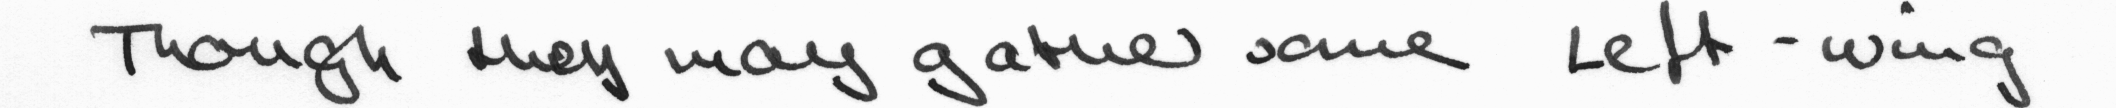


=== Line 2 ===


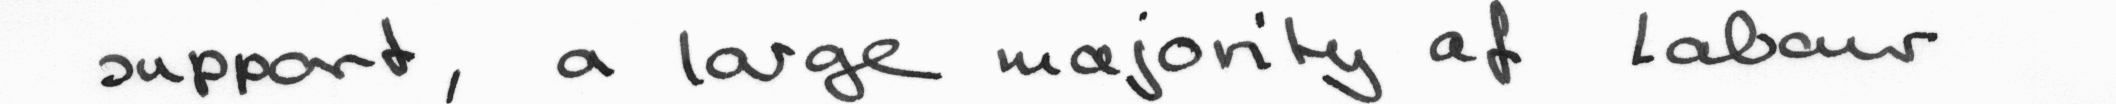


=== Line 3 ===


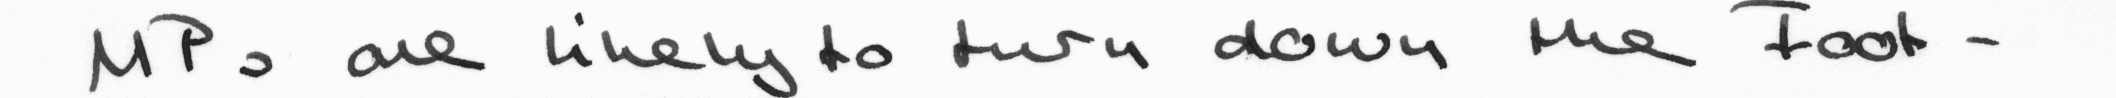


=== Line 4 ===


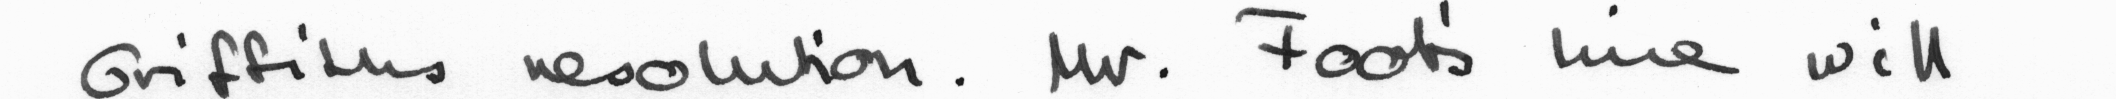


=== Line 5 ===


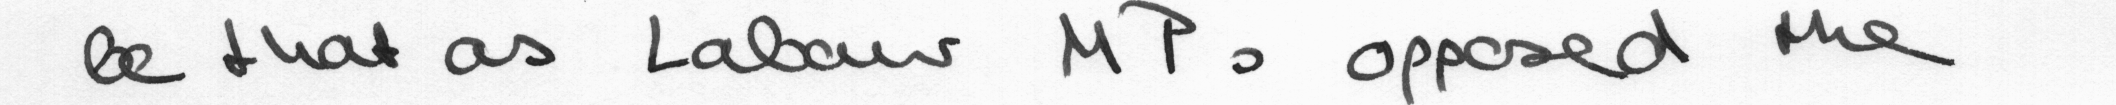


=== Line 6 ===


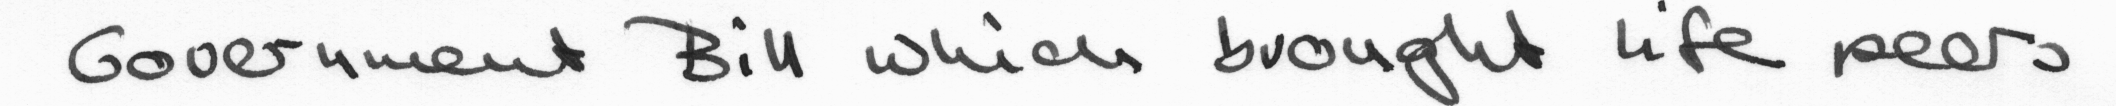


=== Line 7 ===


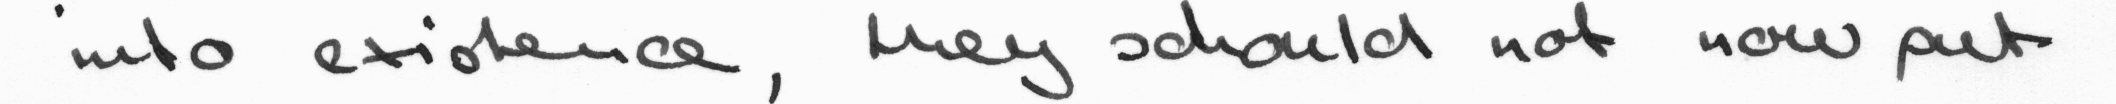


=== Final Recognized Text ===

Though they may gather some Leftwing
support , a large majority of Labour .
MPs are likely to turn down the Foot
Griffiths resolution . Mr. Foot's line will
be that as Labour MPs opposed the
Government Bill which brought life peers
into existence , they should not now put


In [ ]:
import cv2
import numpy as np
import torch
from PIL import Image
from transformers import VisionEncoderDecoderModel, TrOCRProcessor
from google.colab.patches import cv2_imshow
import re
from spellchecker import SpellChecker

# === Line Segmenter ===
class ProperLineSegmentation:
    def preprocess(self, image):
        gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
        _, binary = cv2.threshold(gray, 0, 255, cv2.THRESH_BINARY_INV + cv2.THRESH_OTSU)
        return binary

    def project_horizontal_histogram(self, binary_img):
        return np.sum(binary_img, axis=1)

    def segment_lines(self, image, min_gap=10):
        binary = self.preprocess(image)
        hist = self.project_horizontal_histogram(binary)

        line_positions = []
        in_line = False
        for i, value in enumerate(hist):
            if value > 0:
                if not in_line:
                    start = i
                    in_line = True
            else:
                if in_line:
                    end = i
                    if end - start > min_gap:
                        line_positions.append((start, end))
                    in_line = False

        lines = [image[start:end, :] for (start, end) in line_positions]
        return lines

# === Normalize Text Output ===
def normalize_text(text):
    text = re.sub(r'\s+', ' ', text)  # remove extra spaces/newlines
    text = re.sub(r'(\b\w+\b)( \1\b)+', r'\1', text)  # remove repeated words
    text = re.sub(r'[^a-zA-Z0-9.,;:!?()\[\]\'" ]', '', text)  # remove unwanted characters
    return text.strip()

# === Spell Correction ===
def correct_spelling(text):
    spell = SpellChecker()
    whitelist = {"AI", "OCR", "CNN", "ML", "NLP"}  # preserve important terms

    words = text.split()
    corrected = []
    for w in words:
        if w.lower() in whitelist or w not in spell.unknown([w]):
            corrected.append(w)
        else:
            suggestion = spell.correction(w)
            corrected.append(suggestion if suggestion else w)  # fallback if None
    return " ".join(corrected)

# === TrOCR-based Recognition Function ===
def recognize_text_with_trocr(image_path, model_size="base"):
    assert model_size in ["base", "large"], "Choose 'base' or 'large'"

    # Load model
    model_name = f"microsoft/trocr-{model_size}-handwritten"
    processor = TrOCRProcessor.from_pretrained(model_name)
    model = VisionEncoderDecoderModel.from_pretrained(model_name)
    device = "cuda" if torch.cuda.is_available() else "cpu"
    model.to(device)

    # Read and segment image
    image = cv2.imread(image_path)
    segmenter = ProperLineSegmentation()
    lines = segmenter.segment_lines(image)

    full_text = []

    for idx, line in enumerate(lines):
        if line.shape[0] < 10:
            continue  # skip noise/small lines

        print(f"\n=== Line {idx + 1} ===")
        cv2_imshow(line)

        # Convert to PIL
        if len(line.shape) == 2:
            line = cv2.cvtColor(line, cv2.COLOR_GRAY2BGR)
        pil_img = Image.fromarray(line)

        # Preprocess and predict
        pixel_values = processor(pil_img, return_tensors="pt").pixel_values.to(device)
        with torch.no_grad():
            generated_ids = model.generate(pixel_values, max_length=512)
        text = processor.batch_decode(generated_ids, skip_special_tokens=True)[0]

        # Apply post-processing: Normalization and Spell Correction
        text = normalize_text(text)
        text = correct_spelling(text)

        full_text.append(text)

    final_result = "\n".join(full_text)
    print("\n=== Final Recognized Text ===\n")
    print(final_result)
    return final_result

# === Run ===
image_path = "/content/drive/MyDrive/images/000002.png"  # Change this to your image path
final_output = recognize_text_with_trocr(image_path, model_size="base")  # or use "large"

ADVANCED POST PROCESSING

In [1]:
!pip install opencv-python-headless torch torchvision torchaudio transformers Pillow pyspellchecker

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 4.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.8/13.8 MB 61.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.6/24.6 MB 44.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 883.7/883.7 kB 36.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 1.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.5/211.5 MB 6.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 12.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 127.9/127.9 MB 7.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.5/207.5 MB 6.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 21.1/21.1 MB 50.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.1/7.1 MB 59.8 MB/s eta 0:00:00
  Attempting uninstall: nvidia-nvjitlink-cu12
    Found existing installation: nvidia-nvjitlink-cu12 12.5.82
    Uninstalling 

Config of the encoder: <class 'transformers.models.vit.modeling_vit.ViTModel'> is overwritten by shared encoder config: ViTConfig {
  "attention_probs_dropout_prob": 0.0,
  "encoder_stride": 16,
  "hidden_act": "gelu",
  "hidden_dropout_prob": 0.0,
  "hidden_size": 768,
  "image_size": 384,
  "initializer_range": 0.02,
  "intermediate_size": 3072,
  "layer_norm_eps": 1e-12,
  "model_type": "vit",
  "num_attention_heads": 12,
  "num_channels": 3,
  "num_hidden_layers": 12,
  "patch_size": 16,
  "pooler_act": "tanh",
  "pooler_output_size": 768,
  "qkv_bias": false,
  "torch_dtype": "float32",
  "transformers_version": "4.50.3"
}

Config of the decoder: <class 'transformers.models.trocr.modeling_trocr.TrOCRForCausalLM'> is overwritten by shared decoder config: TrOCRConfig {
  "activation_dropout": 0.0,
  "activation_function": "gelu",
  "add_cross_attention": true,
  "attention_dropout": 0.0,
  "bos_token_id": 0,
  "classifier_dropout": 0.0,
  "cross_attention_hidden_size": 768,
  "d_mod


=== Line 1 ===


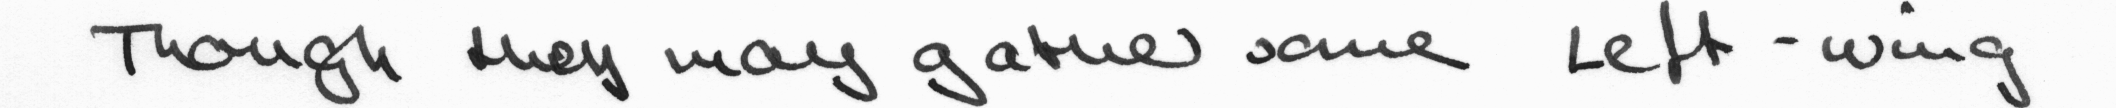


=== Line 2 ===


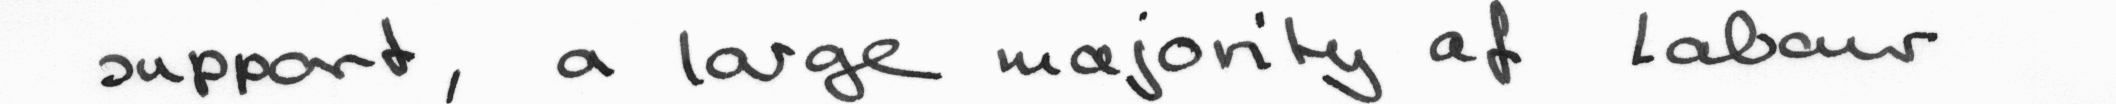


=== Line 3 ===


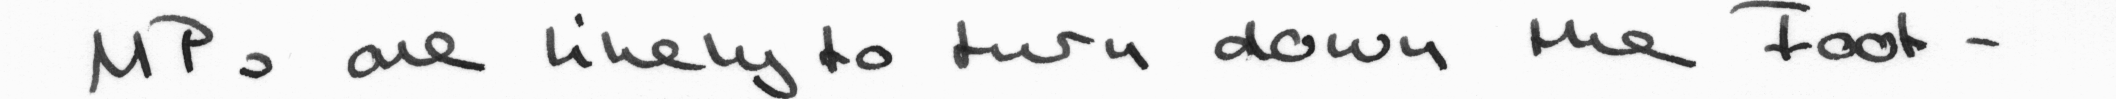


=== Line 4 ===


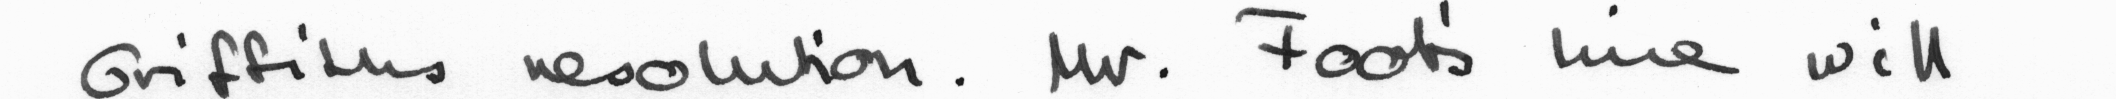


=== Line 5 ===


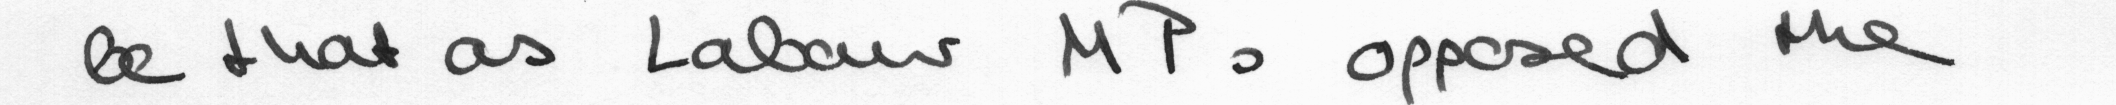


=== Line 6 ===


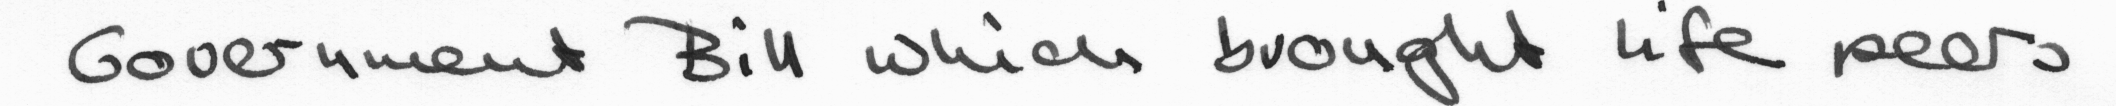


=== Line 7 ===


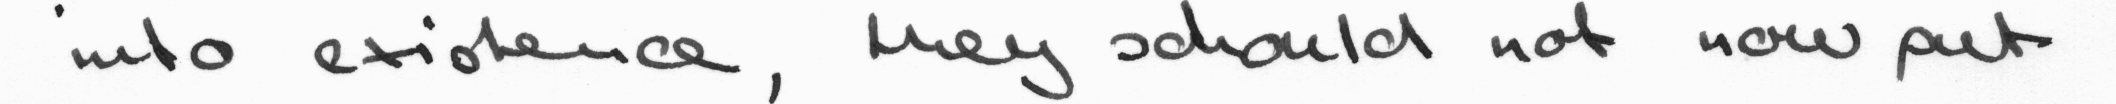


=== Final Recognized Text ===

Though they may gather some Leftwing
support , a large majority of Labour .
MPs are likely to turn down the Foot
Griffiths resolution . Mr. Foot's line will
be that as Labour MPs opposed the
Government Bill which brought life peers
into existence , they should not now put


In [8]:
import cv2
import numpy as np
import torch
from PIL import Image
from transformers import VisionEncoderDecoderModel, TrOCRProcessor, AutoModelForSeq2SeqLM, AutoTokenizer
from google.colab.patches import cv2_imshow
import re
from spellchecker import SpellChecker

# === Line Segmenter ===
class ProperLineSegmentation:
    def preprocess(self, image):
        gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
        clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8))
        enhanced = clahe.apply(gray)
        _, binary = cv2.threshold(enhanced, 0, 255, cv2.THRESH_BINARY_INV + cv2.THRESH_OTSU)
        return binary

    def project_horizontal_histogram(self, binary_img):
        return np.sum(binary_img, axis=1)

    def segment_lines(self, image, min_gap=10):
        binary = self.preprocess(image)
        hist = self.project_horizontal_histogram(binary)

        line_positions = []
        in_line = False
        for i, value in enumerate(hist):
            if value > 0:
                if not in_line:
                    start = i
                    in_line = True
            else:
                if in_line:
                    end = i
                    if end - start > min_gap:
                        line_positions.append((start, end))
                    in_line = False

        lines = [image[start:end, :] for (start, end) in line_positions]
        return lines

# === Normalize Text Output ===
def normalize_text(text):
    text = re.sub(r'\s+', ' ', text)
    text = re.sub(r'(\b\w+\b)( \1\b)+', r'\1', text)
    text = re.sub(r'[^a-zA-Z0-9.,;:!?()\[\]\'" ]', '', text)
    return text.strip()

# === Spell Correction ===
def correct_spelling(text):
    spell = SpellChecker()
    whitelist = {"AI", "OCR", "CNN", "ML", "NLP"}
    words = text.split()
    corrected = []
    for w in words:
        if w.lower() in whitelist or w not in spell.unknown([w]):
            corrected.append(w)
        else:
            suggestion = spell.correction(w)
            corrected.append(suggestion if suggestion else w)
    return " ".join(corrected)


use_advanced_postprocessing = False

def restore_punctuation(text):
    model_name = "oliverguhr/fullstop-punctuation-multilang-large"
    tokenizer = AutoTokenizer.from_pretrained(model_name)
    model = AutoModelForSeq2SeqLM.from_pretrained(model_name).to("cuda" if torch.cuda.is_available() else "cpu")

    inputs = tokenizer(text, return_tensors="pt", padding=True, truncation=True).to(model.device)
    with torch.no_grad():
        outputs = model.generate(**inputs)
    restored = tokenizer.batch_decode(outputs, skip_special_tokens=True)[0]
    return restored

def segment_sentences(text):
    return re.sub(r'([.?!])\s+', r'\1\n', text)

def correct_context(text):
    model_name = "pszemraj/flan-t5-base-grammar-synthesis"
    tokenizer = AutoTokenizer.from_pretrained(model_name)
    model = AutoModelForSeq2SeqLM.from_pretrained(model_name).to("cuda" if torch.cuda.is_available() else "cpu")

    inputs = tokenizer(f"grammar: {text}", return_tensors="pt", padding=True, truncation=True).to(model.device)
    with torch.no_grad():
        outputs = model.generate(**inputs)
    corrected = tokenizer.batch_decode(outputs, skip_special_tokens=True)[0]
    return corrected

# === TrOCR-based Recognition Function ===
def recognize_text_with_trocr(image_path, model_size="base"):
    assert model_size in ["base", "large"]

    model_name = f"microsoft/trocr-{model_size}-handwritten"
    processor = TrOCRProcessor.from_pretrained(model_name)
    model = VisionEncoderDecoderModel.from_pretrained(model_name)
    device = "cuda" if torch.cuda.is_available() else "cpu"
    model.to(device)

    image = cv2.imread(image_path)
    if image is None:
        raise ValueError("Failed to load image. Check path.")

    segmenter = ProperLineSegmentation()
    lines = segmenter.segment_lines(image)

    full_text = []

    for idx, line in enumerate(lines):
        if line.shape[0] < 10:
            continue

        print(f"\n=== Line {idx + 1} ===")
        cv2_imshow(line)

        resized = cv2.resize(line, (min(1024, line.shape[1]), 64), interpolation=cv2.INTER_LINEAR)
        if len(resized.shape) == 2:
            resized = cv2.cvtColor(resized, cv2.COLOR_GRAY2RGB)
        elif resized.shape[2] == 1:
            resized = cv2.cvtColor(resized, cv2.COLOR_GRAY2RGB)
        pil_img = Image.fromarray(resized)

        pixel_values = processor(pil_img, return_tensors="pt").pixel_values.to(device)
        with torch.no_grad():
            generated_ids = model.generate(pixel_values, max_length=512)
        text = processor.batch_decode(generated_ids, skip_special_tokens=True)[0]

        text = normalize_text(text)
        text = correct_spelling(text)

        if use_advanced_postprocessing:
            text = restore_punctuation(text)
            text = segment_sentences(text)
            text = correct_context(text)

        full_text.append(text)

    final_result = "\n".join(full_text)
    print("\n=== Final Recognized Text ===\n")
    print(final_result)
    return final_result

# === Run ===
image_path = "/content/drive/MyDrive/images/000002.png"
final_output = recognize_text_with_trocr(image_path, model_size="base")


PADDLE OCR

In [ ]:
# Install HuggingFace Transformers and PyTorch
!pip install transformers==4.40.0
!pip install torch torchvision torchaudio

# Install PaddlePaddle and PaddleOCR
!pip install paddlepaddle==2.5.2
!pip install paddleocr==2.7.1

# Install OpenCV and Pillow (already preinstalled in Colab, but just in case)
!pip install opencv-python pillow

# Install Spell Checker
!pip install pyspellchecker


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.0/9.0 MB 77.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 781.7/781.7 kB 41.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.6/3.6 MB 89.6 MB/s eta 0:00:00


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 766.7/766.7 MB 26.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 29.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.8/13.8 MB 169.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.6/24.6 MB 172.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 883.7/883.7 kB 47.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 47.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.5/211.5 MB 73.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 66.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 127.9/127.9 MB 68.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.5/207.5 MB 73.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 150.1/150.1 MB 63.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 188.7/188.7 MB 26.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

/usr/local/lib/python3.11/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(
Using a slow image processor as `use_fast` is unset and a slow processor was saved with this model. `use_fast=True` will be the default behavior in v4.52, even if the model was saved with a slow processor. This will result in minor differences in outputs. You'll still be able to use a slow processor with `use_fast=False`.
Config of the encoder: <class 'transformers.models.vit.modeling_vit.ViTModel'> is overwritten by shared encoder config: ViTConfig {
  "attention_probs_dropout


=== Line 1 ===


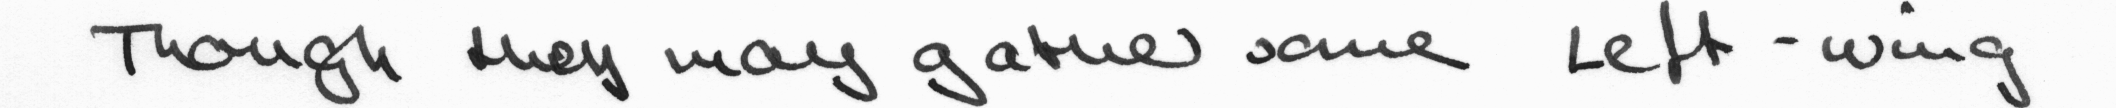


=== Line 2 ===


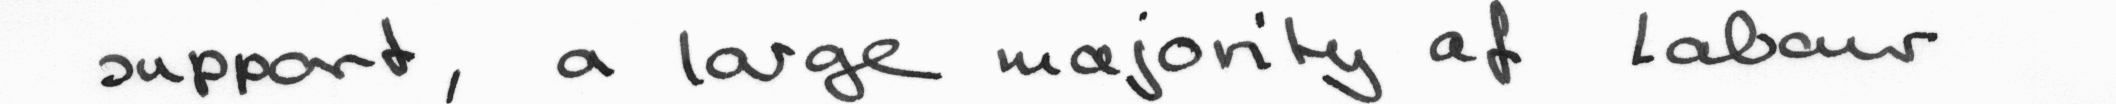


=== Line 3 ===


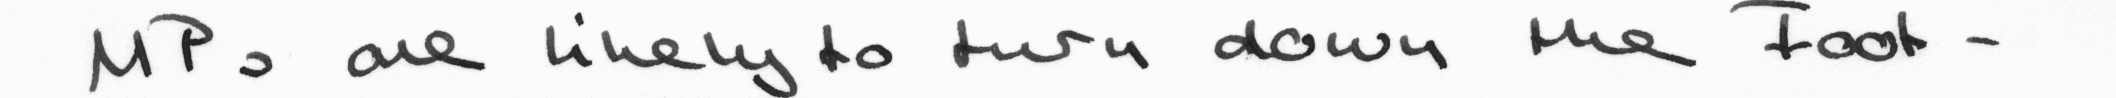


=== Line 4 ===


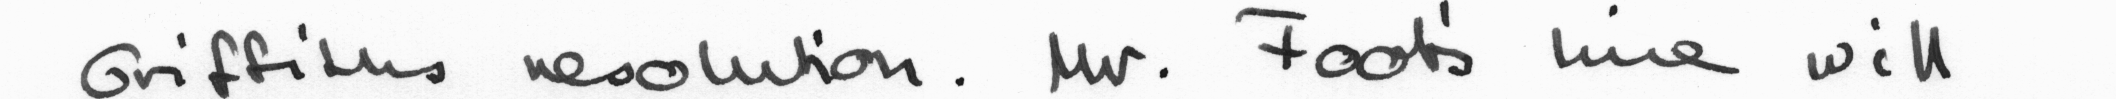


=== Line 5 ===


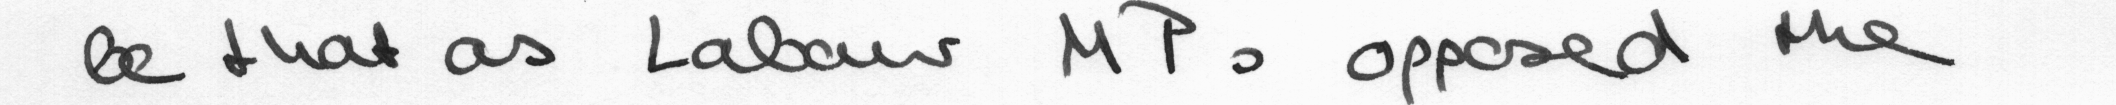


=== Line 6 ===


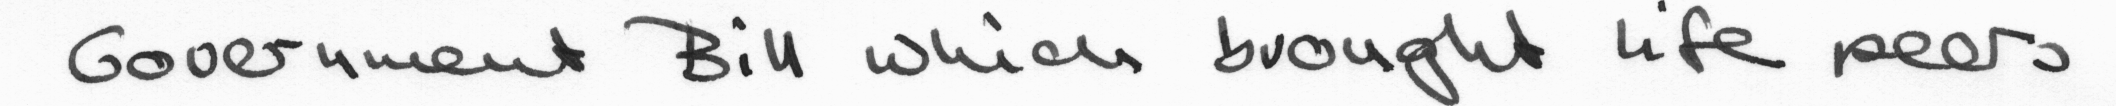


=== Line 7 ===


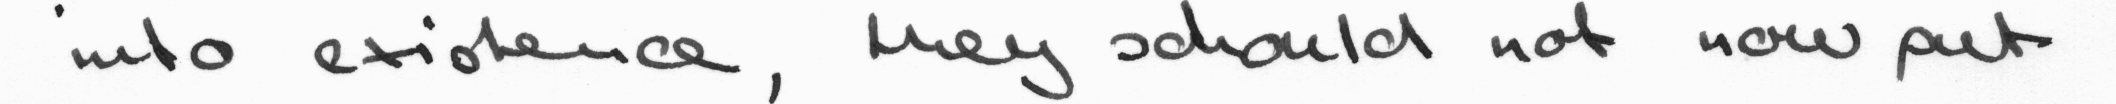


=== Final Recognized Text ===

Though they may gather some Leftwing
support , a large majority of Labour .
MPs are likely to turn down the Foot
Griffiths resolution . Mr. Foot's line will
be that as Labour MPs opposed the
Government Bill which brought life peers
into existence , they should not now put


In [1]:
import cv2
import numpy as np
import torch
from PIL import Image
from transformers import VisionEncoderDecoderModel, TrOCRProcessor
from google.colab.patches import cv2_imshow
import re
from spellchecker import SpellChecker

use_paddleocr = False
if use_paddleocr:
    from paddleocr import PaddleOCR
    ocr_engine = PaddleOCR(use_angle_cls=True, lang='en')

# === Line Segmenter (OpenCV-based) ===
class ProperLineSegmentation:
    def preprocess(self, image):
        gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
        _, binary = cv2.threshold(gray, 0, 255, cv2.THRESH_BINARY_INV + cv2.THRESH_OTSU)
        return binary

    def project_horizontal_histogram(self, binary_img):
        return np.sum(binary_img, axis=1)

    def segment_lines(self, image, min_gap=10):
        binary = self.preprocess(image)
        hist = self.project_horizontal_histogram(binary)

        line_positions = []
        in_line = False
        for i, value in enumerate(hist):
            if value > 0:
                if not in_line:
                    start = i
                    in_line = True
            else:
                if in_line:
                    end = i
                    if end - start > min_gap:
                        line_positions.append((start, end))
                    in_line = False

        lines = [image[start:end, :] for (start, end) in line_positions]
        return lines

# === PaddleOCR-based Line Segmenter (Hybrid Option) ===
def segment_lines_with_paddleocr(image):
    results = ocr_engine.ocr(image)
    boxes = [line[0] for block in results for line in block]
    cropped_lines = []

    for box in boxes:
        x_coords = [int(pt[0]) for pt in box]
        y_coords = [int(pt[1]) for pt in box]
        x_min, x_max = max(min(x_coords), 0), min(max(x_coords), image.shape[1])
        y_min, y_max = max(min(y_coords), 0), min(max(y_coords), image.shape[0])
        cropped_line = image[y_min:y_max, x_min:x_max]
        if cropped_line.shape[0] > 10:
            cropped_lines.append(cropped_line)

    return cropped_lines

# === Normalize Text Output ===
def normalize_text(text):
    text = re.sub(r'\s+', ' ', text)  # remove extra spaces/newlines
    text = re.sub(r'(\b\w+\b)( \1\b)+', r'\1', text)  # remove repeated words
    text = re.sub(r'[^a-zA-Z0-9.,;:!?()\[\]\'" ]', '', text)  # remove unwanted characters
    return text.strip()

# === Spell Correction ===
def correct_spelling(text):
    spell = SpellChecker()
    whitelist = {"AI", "OCR", "CNN", "ML", "NLP"}  # preserve important terms

    words = text.split()
    corrected = []
    for w in words:
        if w.lower() in whitelist or w not in spell.unknown([w]):
            corrected.append(w)
        else:
            suggestion = spell.correction(w)
            corrected.append(suggestion if suggestion else w)  # fallback if None
    return " ".join(corrected)

# === TrOCR-based Recognition Function ===
def recognize_text_with_trocr(image_path, model_size="base"):
    assert model_size in ["base", "large"], "Choose 'base' or 'large'"

    # Load model
    model_name = f"microsoft/trocr-{model_size}-handwritten"
    processor = TrOCRProcessor.from_pretrained(model_name)
    model = VisionEncoderDecoderModel.from_pretrained(model_name)
    device = "cuda" if torch.cuda.is_available() else "cpu"
    model.to(device)

    # Read and segment image
    image = cv2.imread(image_path)

    if use_paddleocr:
        lines = segment_lines_with_paddleocr(image)
    else:
        segmenter = ProperLineSegmentation()
        lines = segmenter.segment_lines(image)

    full_text = []

    for idx, line in enumerate(lines):
        if line.shape[0] < 10:
            continue  # skip noise/small lines

        print(f"\n=== Line {idx + 1} ===")
        cv2_imshow(line)

        # Convert to PIL
        if len(line.shape) == 2:
            line = cv2.cvtColor(line, cv2.COLOR_GRAY2BGR)
        pil_img = Image.fromarray(line)

        # Preprocess and predict
        pixel_values = processor(pil_img, return_tensors="pt").pixel_values.to(device)
        with torch.no_grad():
            generated_ids = model.generate(pixel_values, max_length=512)
        text = processor.batch_decode(generated_ids, skip_special_tokens=True)[0]

        # Apply post-processing: Normalization and Spell Correction
        text = normalize_text(text)
        text = correct_spelling(text)

        full_text.append(text)

    final_result = "\n".join(full_text)
    print("\n=== Final Recognized Text ===\n")
    print(final_result)
    return final_result

# === Run ===
image_path = "/content/drive/MyDrive/images/000002.png"  # Change this to your image path
final_output = recognize_text_with_trocr(image_path, model_size="base")  # or use "large"
